
# Navier–Stokes PINNsFormer：M-ConFIG-4 Fixed Round-Robin × 3 Seeds

这个 notebook 是当前 `ConFIG-4` 实验的下一阶段：**先忠实保留官方 M-ConFIG 的核心语义，验证固定轮询（fixed round-robin）降低真实 task-gradient 刷新频率后，精度、物理误差、耗时和梯度陈旧度发生什么变化。**

四个原始任务仍然是：

$$
L_1=L_{u,\mathrm{data}},\qquad
L_2=L_{v,\mathrm{data}},\qquad
L_3=L_{f_u},\qquad
L_4=L_{f_v}.
$$

标准 ConFIG-4 每个 optimizer step 都需要 fresh：

$$
g_u,\ g_v,\ g_{f_u},\ g_{f_v}.
$$

M-ConFIG fixed round-robin 每一步只真实刷新一个：

```text
step 0 -> u_data
step 1 -> v_data
step 2 -> f_u
step 3 -> f_v
step 4 -> u_data
...
```

其余梯度由 `PseudoMomentumOperator` 内部保存的 momentum estimate 提供。

## 本 notebook 为什么不只跑一个 M-ConFIG

为了回答“少刷新梯度到底损失了什么”，这里同时跑两个 **optimizer-matched control**：

1. **Full-Refresh PseudoMomentum Control**
   - 四个 task gradient 每 step 全部 fresh；
   - `PseudoMomentumOperator + SGD`；
   - 用来隔离 pseudo-momentum / SGD 本身的影响。

2. **M-ConFIG-4 Fixed Round-Robin**
   - 每 step 只 fresh 一个 task gradient；
   - 同一个 `PseudoMomentumOperator + SGD`；
   - 固定 `step % 4` 轮询。

这样最关键的比较是：

$$
\boxed{
\text{Full-Refresh PseudoMomentum}
\quad\mathrm{vs}\quad
\text{Fixed-Round-Robin M-ConFIG}
}
$$

两边网络、数据、loss、SGD、学习率、训练预算都相同，核心差异是：

$$
4\ \text{fresh task gradients / step}
\quad\rightarrow\quad
1\ \text{fresh task gradient / step}.
$$

> 当前已有 Adam / ConFIG-2 / ConFIG-4 结果仍作为历史上下文，但因为外层 optimizer 不同，不能把它们与本次 M-ConFIG 的差异全部归因于“刷新策略”。

## 官方语义边界

本 notebook 不是 `tum-pbs/ConFIG` 官方 Navier–Stokes 实验；它是把官方 M-ConFIG **机制语义**适配到当前 PINNsFormer benchmark：

- `PseudoMomentumOperator`；
- 外层 `SGD`；
- fixed round-robin；
- 一次只真实计算被选中的 task gradient；
- 初始化阶段在四个 task 都至少刷新一次之前，operator 返回零更新。

当前 benchmark、网络、800 点采样和学习率属于本项目适配设置。



## 这次最需要关注的 5 个问题

### Q1. 真实梯度刷新从 4000 次降到约 1000 次，wall time 到底省多少？

标准 4-loss full-refresh 在 1000 step 下：

$$
4\times1000=4000
$$

次高层 task-parameter-gradient extraction。

fixed round-robin：

$$
1\times1000=1000.
$$

但 wall time 不一定下降 75%，因为 Navier–Stokes 高阶自动微分、forward、ConFIG 组合等也占时间。

### Q2. stale gradient 多旧？

定义 task $i$ 在 step $t$ 的年龄：

$$
s_i(t)=t-t_i^{\mathrm{last\ refresh}}.
$$

4-loss fixed round-robin 在初始化完成后典型年龄为 0–3 step。

### Q3. stale estimate 还像当前 fresh gradient 吗？

周期性 probe：

$$
\cos\left(\hat g_i^{\mathrm{momentum}},g_i^{\mathrm{fresh}}\right).
$$

如果 age 增大时 cosine 系统性下降，说明固定轮询确实带来“信息陈旧”。

### Q4. M-ConFIG 最终更新方向对当前 fresh gradients 还安全吗？

测：

$$
\cos(g_{\mathrm{MConFIG}},g_i^{\mathrm{fresh}})
$$

以及：

$$
\min_i\cos(g_{\mathrm{MConFIG}},g_i^{\mathrm{fresh}}).
$$

标准 ConFIG-4 已经观察到公共方向对四个 fresh task gradients 保持正 alignment；M-ConFIG 使用历史估计后，这个性质相对于**当前 fresh gradient** 是否仍保持，是本阶段最关键的机制问题之一。

### Q5. 省计算以后，场重建精度和 physics convergence 损失多少？

继续报告：

- $u/v$ Relative L2；
- raw / mean-aligned pressure Relative L2；
- mean / final physics loss；
- physics threshold step；
- **time-to-target**；
- core peak VRAM；
- wall time；
- fresh task-gradient refresh count。


In [1]:

from pathlib import Path
import os
import sys
import time
import json
import csv
import gc
import random
import math

import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

print("Python executable:", sys.executable)
print("Python version   :", sys.version.split()[0])
print("PyTorch          :", torch.__version__)
print("CUDA runtime     :", torch.version.cuda)
print("CUDA available   :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU              :", torch.cuda.get_device_name(0))


Python executable: /home/simplexity/anaconda3/envs/config_pinn/bin/python
Python version   : 3.10.21
PyTorch          : 2.5.1+cu121
CUDA runtime     : 12.1
CUDA available   : True
GPU              : NVIDIA GeForce GTX 1080 Ti


## 1. 路径与实验配置

In [2]:

PINNSFORMER_ROOT = Path(
    os.environ.get("PINNSFORMER_ROOT", "/home/simplexity/cyt/pinnsformer-main")
)

EXPERIMENT_ROOT = Path(
    os.environ.get(
        "PINNSFORMER_CONFIG_ROOT",
        str(PINNSFORMER_ROOT / "pinnsformer-config"),
    )
)

CONFIG_ROOT = Path(
    os.environ.get("CONFIG_ROOT", "/home/simplexity/cyt/ConFIG-main")
)

DATA_PATH = (
    PINNSFORMER_ROOT
    / "demo"
    / "navier_stokes"
    / "cylinder_nektar_wake.mat"
)

# 历史 4-loss 结果，仅用于最后的上下文表，不作为本次因果 control。
PREVIOUS_4LOSS_ROOT = (
    EXPERIMENT_ROOT
    / "outputs"
    / "navier_stokes_4loss_multiseed"
)

OUTPUT_ROOT = (
    EXPERIMENT_ROOT
    / "outputs"
    / "navier_stokes_mconfig4_fixed_roundrobin"
)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# ===== 正式实验 =====
RUN_SEEDS = [0, 1, 2]
FORCE_RERUN = False

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
N_TRAIN = 800
NUM_STEP = 5
TIME_STEP = 1e-2
EPOCHS = 1000
SNAPSHOT = 100

# 与此前 Adam/ConFIG 实验保持同一“名义 lr”作为本 benchmark 的首个适配值。
# 重要：这不是官方针对 PINNsFormer/Navier-Stokes 给出的超参数。
SGD_LR = 1e-4

BETA_1 = 0.9
BETA_2 = 0.999

# 每 10 step 评估一次完整四项 loss，用于 physics threshold。
METRIC_INTERVAL = 10

# 每 50 step 做一次 fresh-gradient probe：
# 比较 cached momentum estimate vs 当前 fresh gradient。
PROBE_INTERVAL = 50

PHYSICS_THRESHOLDS = [1e-2, 5e-3, 2e-3, 1e-3, 5e-4]

LOSS_KEYS = ["u_data", "v_data", "f_u", "f_v"]
LOSS_INDEX = {name: i for i, name in enumerate(LOSS_KEYS)}

METHODS = [
    "full_refresh_pseudo_sgd",
    "mconfig4_fixed_roundrobin",
]

print("PINNSFORMER_ROOT :", PINNSFORMER_ROOT)
print("EXPERIMENT_ROOT  :", EXPERIMENT_ROOT)
print("CONFIG_ROOT      :", CONFIG_ROOT)
print("DATA_PATH        :", DATA_PATH)
print("OUTPUT_ROOT      :", OUTPUT_ROOT)
print("DEVICE           :", DEVICE)
print("RUN_SEEDS        :", RUN_SEEDS)
print("SGD_LR           :", SGD_LR)
print("METRIC_INTERVAL  :", METRIC_INTERVAL)
print("PROBE_INTERVAL   :", PROBE_INTERVAL)


PINNSFORMER_ROOT : /home/simplexity/cyt/pinnsformer-main
EXPERIMENT_ROOT  : /home/simplexity/cyt/pinnsformer-main/pinnsformer-config
CONFIG_ROOT      : /home/simplexity/cyt/ConFIG-main
DATA_PATH        : /home/simplexity/cyt/pinnsformer-main/demo/navier_stokes/cylinder_nektar_wake.mat
OUTPUT_ROOT      : /home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_mconfig4_fixed_roundrobin
DEVICE           : cuda:0
RUN_SEEDS        : [0, 1, 2]
SGD_LR           : 0.0001
METRIC_INTERVAL  : 10
PROBE_INTERVAL   : 50



### 学习率说明

官方 ConFIG PINN 仓库的 momentum trainer 使用外层 SGD；官方 Burgers 配置使用自己的学习率/调度设置。当前 PINNsFormer Navier–Stokes 并不是官方 M-ConFIG benchmark，所以这里首先使用 `SGD_LR=1e-4`，目的是让两个新的 SGD+pseudo-momentum 方法彼此公平，并保持与此前实验相同的名义步长量级。

如果 seed=0 出现明显发散或几乎不学习，**不要只给 fixed round-robin 单独调参**。应当对 `full_refresh_pseudo_sgd` 和 `mconfig4_fixed_roundrobin` 使用相同 LR 候选一起做短跑，再冻结一个共享设置。


## 2. 导入当前公共实现与官方 M-ConFIG operator

In [3]:

assert DATA_PATH.exists(), f"Missing dataset: {DATA_PATH}"
assert (EXPERIMENT_ROOT / "navier_stokes_common.py").exists()
assert (EXPERIMENT_ROOT / "gradient_diagnostics.py").exists()
assert CONFIG_ROOT.exists()

sys.path.insert(0, str(EXPERIMENT_ROOT))
sys.path.insert(0, str(CONFIG_ROOT))

from navier_stokes_common import (
    PINNsformer,
    init_weights,
    get_n_params,
    load_training_data,
    compute_ns_losses,
    evaluation_tensors,
)
from gradient_diagnostics import gradient_vector, cosine_similarity

from conflictfree.grad_operator import ConFIGOperator
from conflictfree.momentum_operator import PseudoMomentumOperator
from conflictfree.utils import apply_gradient_vector_para_based

import conflictfree
print("conflictfree:", conflictfree.__file__)


conflictfree: /home/simplexity/cyt/ConFIG-main/conflictfree/__init__.py


## 3. 通用工具

In [4]:

def set_seed(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


def sync_cuda():
    if torch.cuda.is_available():
        torch.cuda.synchronize()


def ensure_dir(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


def write_rows(path, rows, fieldnames=None):
    rows = list(rows)
    if not rows:
        return
    if fieldnames is None:
        fieldnames = list(rows[0].keys())
    with Path(path).open("w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def read_rows(path):
    with Path(path).open("r", newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


def safe_mean(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    return float(arr.mean()) if len(arr) else float("nan")


def safe_std(values):
    arr = np.asarray(values, dtype=float)
    arr = arr[np.isfinite(arr)]
    if len(arr) <= 1:
        return float("nan")
    return float(arr.std(ddof=1))


def relative_l2(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return float(np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true))


def mae(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return float(np.mean(np.abs(y_true - y_pred)))


def max_abs_error(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return float(np.max(np.abs(y_true - y_pred)))


def align_pressure_mean(p_true, p_pred):
    p_true = np.asarray(p_true).reshape(-1)
    p_pred = np.asarray(p_pred).reshape(-1)
    return p_pred - np.mean(p_pred) + np.mean(p_true)


def model_name(method):
    return {
        "full_refresh_pseudo_sgd": "Full-Refresh PseudoMomentum + SGD",
        "mconfig4_fixed_roundrobin": "M-ConFIG-4 Fixed RR + SGD",
    }[method]


def make_model(device):
    model = PINNsformer(
        d_out=2,
        d_hidden=512,
        d_model=32,
        N=1,
        heads=2,
    ).to(device)
    model.apply(init_weights)
    return model



## 4. 为什么需要“单 task loss”实现

官方 momentum trainer 每个 epoch 只调用被选中的一个 loss function，再计算它的真实梯度。

如果我们在 fixed round-robin 中仍然先执行完整 `compute_ns_losses()`，虽然最后只对一个 loss 求参数梯度，但实际上四个 loss 的高阶 PDE 图已经全部算完，会把 M-ConFIG 的计算优势人为削弱。

因此这里实现：

```text
u_data -> 只构造 u 数据损失所需计算
v_data -> 只构造 v 数据损失所需计算
f_u    -> 只构造第一条 NS momentum residual 所需计算
f_v    -> 只构造第二条 NS momentum residual 所需计算
```

下一节会先用小 batch 验证：这些 task-specific loss / gradient 与现有 `compute_ns_losses()` 中相应四项保持一致。


In [5]:

def _psi_pressure(model, x, y, t):
    out = model(x, y, t)
    return out[:, :, 0:1], out[:, :, 1:2]


def compute_single_task_loss(model, batch, task_name):
    x = batch["x"]
    y = batch["y"]
    t = batch["t"]
    u_obs = batch["u"]
    v_obs = batch["v"]

    psi, pressure = _psi_pressure(model, x, y, t)

    if task_name == "u_data":
        u_pred = torch.autograd.grad(
            psi,
            y,
            grad_outputs=torch.ones_like(psi),
            retain_graph=True,
            create_graph=True,
        )[0]
        return torch.mean((u_pred[:, 0] - u_obs) ** 2)

    if task_name == "v_data":
        v_pred = -torch.autograd.grad(
            psi,
            x,
            grad_outputs=torch.ones_like(psi),
            retain_graph=True,
            create_graph=True,
        )[0]
        return torch.mean((v_pred[:, 0] - v_obs) ** 2)

    # 两个 PDE task 都需要当前 u / v。
    u_pred = torch.autograd.grad(
        psi,
        y,
        grad_outputs=torch.ones_like(psi),
        retain_graph=True,
        create_graph=True,
    )[0]
    v_pred = -torch.autograd.grad(
        psi,
        x,
        grad_outputs=torch.ones_like(psi),
        retain_graph=True,
        create_graph=True,
    )[0]

    if task_name == "f_u":
        u_t = torch.autograd.grad(
            u_pred, t,
            grad_outputs=torch.ones_like(u_pred),
            retain_graph=True,
            create_graph=True,
        )[0]
        u_x = torch.autograd.grad(
            u_pred, x,
            grad_outputs=torch.ones_like(u_pred),
            retain_graph=True,
            create_graph=True,
        )[0]
        u_y = torch.autograd.grad(
            u_pred, y,
            grad_outputs=torch.ones_like(u_pred),
            retain_graph=True,
            create_graph=True,
        )[0]
        u_xx = torch.autograd.grad(
            u_x, x,
            grad_outputs=torch.ones_like(u_x),
            retain_graph=True,
            create_graph=True,
        )[0]
        u_yy = torch.autograd.grad(
            u_y, y,
            grad_outputs=torch.ones_like(u_y),
            retain_graph=True,
            create_graph=True,
        )[0]
        p_x = torch.autograd.grad(
            pressure, x,
            grad_outputs=torch.ones_like(pressure),
            retain_graph=True,
            create_graph=True,
        )[0]

        f_u = (
            u_t
            + (u_pred * u_x + v_pred * u_y)
            + p_x
            - 0.01 * (u_xx + u_yy)
        )
        return torch.mean(f_u ** 2)

    if task_name == "f_v":
        v_t = torch.autograd.grad(
            v_pred, t,
            grad_outputs=torch.ones_like(v_pred),
            retain_graph=True,
            create_graph=True,
        )[0]
        v_x = torch.autograd.grad(
            v_pred, x,
            grad_outputs=torch.ones_like(v_pred),
            retain_graph=True,
            create_graph=True,
        )[0]
        v_y = torch.autograd.grad(
            v_pred, y,
            grad_outputs=torch.ones_like(v_pred),
            retain_graph=True,
            create_graph=True,
        )[0]
        v_xx = torch.autograd.grad(
            v_x, x,
            grad_outputs=torch.ones_like(v_x),
            retain_graph=True,
            create_graph=True,
        )[0]
        v_yy = torch.autograd.grad(
            v_y, y,
            grad_outputs=torch.ones_like(v_y),
            retain_graph=True,
            create_graph=True,
        )[0]
        p_y = torch.autograd.grad(
            pressure, y,
            grad_outputs=torch.ones_like(pressure),
            retain_graph=True,
            create_graph=True,
        )[0]

        f_v = (
            v_t
            + (u_pred * v_x + v_pred * v_y)
            + p_y
            - 0.01 * (v_xx + v_yy)
        )
        return torch.mean(f_v ** 2)

    raise ValueError(f"Unknown task: {task_name}")


## 5. Smoke test：单 task 实现必须与原四项 loss / gradient 对齐

In [6]:

RUN_IMPLEMENTATION_SMOKE_TEST = True
SMOKE_N = 32

if RUN_IMPLEMENTATION_SMOKE_TEST:
    device = torch.device(DEVICE)

    set_seed(123)
    smoke_batch, _ = load_training_data(
        DATA_PATH,
        device,
        seed=123,
        n_train=SMOKE_N,
        num_step=NUM_STEP,
        time_step=TIME_STEP,
    )

    set_seed(123)
    smoke_model = make_model(device)

    # reference：现有统一 full-loss 实现
    full_losses = compute_ns_losses(
        smoke_model,
        smoke_batch["x"],
        smoke_batch["y"],
        smoke_batch["t"],
        smoke_batch["u"],
        smoke_batch["v"],
    )

    full_grads = {}
    for i, key in enumerate(LOSS_KEYS):
        full_grads[key] = gradient_vector(
            full_losses[key],
            smoke_model,
            retain_graph=(i < len(LOSS_KEYS) - 1),
        )
    full_values = {
        key: float(full_losses[key].detach())
        for key in LOSS_KEYS
    }

    del full_losses
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    rows = []
    for key in LOSS_KEYS:
        task_loss = compute_single_task_loss(
            smoke_model,
            smoke_batch,
            key,
        )
        task_grad = gradient_vector(
            task_loss,
            smoke_model,
            retain_graph=False,
        )

        task_value = float(task_loss.detach())
        ref_value = full_values[key]
        rel_loss_diff = abs(task_value - ref_value) / max(abs(ref_value), 1e-12)
        grad_cos = cosine_similarity(task_grad, full_grads[key])
        grad_rel_norm_diff = float(
            (task_grad - full_grads[key]).norm()
            / (full_grads[key].norm() + 1e-12)
        )

        rows.append({
            "task": key,
            "full_loss": ref_value,
            "single_loss": task_value,
            "relative_loss_diff": rel_loss_diff,
            "gradient_cosine": grad_cos,
            "gradient_relative_norm_diff": grad_rel_norm_diff,
        })

        del task_loss, task_grad

    for row in rows:
        print(row)

    max_loss_diff = max(r["relative_loss_diff"] for r in rows)
    min_grad_cos = min(r["gradient_cosine"] for r in rows)
    print()
    print("max relative loss diff:", max_loss_diff)
    print("min gradient cosine   :", min_grad_cos)

    # 允许浮点计算带来极小差异，但方向必须几乎一致。
    assert max_loss_diff < 1e-5, "single-task loss does not match common implementation"
    assert min_grad_cos > 0.9999, "single-task gradient does not match common implementation"

    del smoke_model, smoke_batch, full_grads
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print("Smoke test passed.")
else:
    print("Smoke test skipped.")


{'task': 'u_data', 'full_loss': 0.8734605312347412, 'single_loss': 0.8734605312347412, 'relative_loss_diff': 0.0, 'gradient_cosine': 1.0000001192092896, 'gradient_relative_norm_diff': 0.0}
{'task': 'v_data', 'full_loss': 0.19829295575618744, 'single_loss': 0.19829295575618744, 'relative_loss_diff': 0.0, 'gradient_cosine': 0.9999998807907104, 'gradient_relative_norm_diff': 0.0}
{'task': 'f_u', 'full_loss': 0.09273136407136917, 'single_loss': 0.09273136407136917, 'relative_loss_diff': 0.0, 'gradient_cosine': 1.0000001192092896, 'gradient_relative_norm_diff': 9.120757482605768e-08}
{'task': 'f_v', 'full_loss': 0.04754483699798584, 'single_loss': 0.04754483699798584, 'relative_loss_diff': 0.0, 'gradient_cosine': 1.0, 'gradient_relative_norm_diff': 1.1199768579217562e-07}

max relative loss diff: 0.0
min gradient cosine   : 0.9999998807907104
Smoke test passed.


## 6. PseudoMomentum state / staleness 工具

In [7]:

def make_momentum_operator():
    return PseudoMomentumOperator(
        num_vectors=len(LOSS_KEYS),
        beta_1=BETA_1,
        beta_2=BETA_2,
        gradient_operator=ConFIGOperator(),
    )


def get_bias_corrected_m_hats(operator):
    if operator.m is None:
        return None

    estimates = []
    for i in range(operator.num_vectors):
        count = operator.t_grads[i]
        if count <= 0:
            estimates.append(None)
        else:
            estimates.append(
                operator.m[i] / (1 - operator.beta_1 ** count)
            )
    return estimates


def current_ages(step, last_refresh_step):
    ages = []
    for last in last_refresh_step:
        if last < 0:
            ages.append(np.nan)
        else:
            ages.append(float(step - last))
    return ages


def cosine_or_nan(a, b):
    if a is None or b is None:
        return float("nan")
    return cosine_similarity(a, b)


def pairwise_fresh_cosines(fresh_grads):
    out = {}
    for i in range(len(LOSS_KEYS)):
        for j in range(i + 1, len(LOSS_KEYS)):
            a = LOSS_KEYS[i]
            b = LOSS_KEYS[j]
            out[f"fresh_cos_{a}__{b}"] = cosine_similarity(
                fresh_grads[a],
                fresh_grads[b],
            )
    return out


## 7. 完整 loss / fresh-gradient probe

In [8]:

def full_loss_values_and_optional_grads(
    model,
    batch,
    *,
    need_grads=False,
):
    losses = compute_ns_losses(
        model,
        batch["x"],
        batch["y"],
        batch["t"],
        batch["u"],
        batch["v"],
    )

    values = {
        key: float(losses[key].detach())
        for key in [
            "total", "data", "physics",
            "u_data", "v_data", "f_u", "f_v",
        ]
    }

    fresh_grads = None
    if need_grads:
        fresh_grads = {}
        for i, key in enumerate(LOSS_KEYS):
            fresh_grads[key] = gradient_vector(
                losses[key],
                model,
                retain_graph=(i < len(LOSS_KEYS) - 1),
            )

    del losses
    return values, fresh_grads



## 8. 关键：如何理解 PseudoMomentumOperator 的初始化

fixed round-robin 初始状态下四个 task 的 momentum 都还没见过真实梯度。

官方 operator 在尚有 task 未初始化时返回零向量。因此 4-loss 情况：

```text
step 0 -> refresh u_data -> 仍有 3 个未初始化 -> zero update
step 1 -> refresh v_data -> 仍有 2 个未初始化 -> zero update
step 2 -> refresh f_u    -> 仍有 1 个未初始化 -> zero update
step 3 -> refresh f_v    -> 四项完成初始化 -> 第一次非零 M-ConFIG update
```

这不是本 notebook 人为添加的 warm-up，而是 operator 自身语义。

因此结果中会同时记录：

- `outer_steps = 1000`
- `true_task_gradient_refreshes = 1000`
- `effective_nonzero_parameter_updates`，预计 fixed RR 约为 997

不通过额外增加训练步数去“补齐”前三步，因为当前阶段优先保持原固定轮询语义。


## 9. Evaluation：与前面 2/4-loss 实验保持一致

In [9]:

def evaluation_truth(reference, device):
    ev, truth_raw = evaluation_tensors(
        reference,
        device,
        snap=SNAPSHOT,
        num_step=NUM_STEP,
        time_step=TIME_STEP,
    )
    truth = {
        name: np.asarray(value).reshape(-1)
        for name, value in truth_raw.items()
    }
    return ev, truth


def predict_fields(model, ev):
    psi_p = model(ev["x"], ev["y"], ev["t"])
    psi = psi_p[:, :, 0:1]
    p_pred = psi_p[:, :, 1:2]

    u_pred = torch.autograd.grad(
        psi,
        ev["y"],
        grad_outputs=torch.ones_like(psi),
        retain_graph=True,
        create_graph=False,
    )[0]

    v_pred = -torch.autograd.grad(
        psi,
        ev["x"],
        grad_outputs=torch.ones_like(psi),
        retain_graph=False,
        create_graph=False,
    )[0]

    return {
        "u": u_pred.detach().cpu().numpy()[:, 0].reshape(-1),
        "v": v_pred.detach().cpu().numpy()[:, 0].reshape(-1),
        "p": p_pred.detach().cpu().numpy()[:, 0].reshape(-1),
    }


def field_metric_rows(seed, method, truth, pred):
    rows = []
    for field in ["u", "v", "p"]:
        row = {
            "seed": int(seed),
            "method": model_name(method),
            "field": field,
            "relative_l2": relative_l2(truth[field], pred[field]),
            "mae": mae(truth[field], pred[field]),
            "max_absolute_error": max_abs_error(truth[field], pred[field]),
            "mean_aligned_relative_l2": "",
        }
        if field == "p":
            aligned = align_pressure_mean(truth["p"], pred["p"])
            row["mean_aligned_relative_l2"] = relative_l2(
                truth["p"],
                aligned,
            )
        rows.append(row)
    return rows


## 10. Probe 诊断：cached estimate vs fresh gradient

In [10]:

def build_probe_row(
    *,
    seed,
    method,
    step,
    refresh_index,
    operator,
    last_refresh_step,
    g_update,
    fresh_grads,
    full_values,
    algorithm_elapsed_s,
):
    m_hats = get_bias_corrected_m_hats(operator)
    ages = current_ages(step, last_refresh_step)

    row = {
        "seed": int(seed),
        "method": model_name(method),
        "step": int(step),
        "refresh_index": int(refresh_index),
        "refresh_task": LOSS_KEYS[refresh_index],
        "algorithm_elapsed_s": float(algorithm_elapsed_s),
        "operator_all_initialized": bool(operator.all_initialized),
        **full_values,
    }

    if m_hats is not None and all(x is not None for x in m_hats):
        # ConFIG direction BEFORE PseudoMomentum second-moment preconditioning.
        raw_config_from_mhat = operator.gradient_operator.calculate_gradient(
            m_hats
        )
    else:
        raw_config_from_mhat = None

    for i, key in enumerate(LOSS_KEYS):
        row[f"age_{key}"] = ages[i]

        estimate = None if m_hats is None else m_hats[i]
        fresh = fresh_grads[key]

        row[f"cos_estimate_fresh_{key}"] = cosine_or_nan(
            estimate,
            fresh,
        )
        row[f"cos_update_fresh_{key}"] = cosine_or_nan(
            g_update,
            fresh,
        )
        row[f"cos_rawconfig_fresh_{key}"] = cosine_or_nan(
            raw_config_from_mhat,
            fresh,
        )

        if estimate is None:
            row[f"relative_estimate_error_{key}"] = np.nan
        else:
            row[f"relative_estimate_error_{key}"] = float(
                (estimate - fresh).norm()
                / (fresh.norm() + 1e-12)
            )

    update_cos = np.asarray(
        [row[f"cos_update_fresh_{key}"] for key in LOSS_KEYS],
        dtype=float,
    )
    raw_cos = np.asarray(
        [row[f"cos_rawconfig_fresh_{key}"] for key in LOSS_KEYS],
        dtype=float,
    )

    valid_update = update_cos[np.isfinite(update_cos)]
    valid_raw = raw_cos[np.isfinite(raw_cos)]

    row["min_update_fresh_alignment"] = (
        float(valid_update.min())
        if len(valid_update) else np.nan
    )
    row["mean_update_fresh_alignment"] = (
        float(valid_update.mean())
        if len(valid_update) else np.nan
    )
    row["nonpositive_update_fresh_rate"] = (
        float(np.mean(valid_update <= 0))
        if len(valid_update) else np.nan
    )

    row["min_rawconfig_fresh_alignment"] = (
        float(valid_raw.min())
        if len(valid_raw) else np.nan
    )

    row.update(pairwise_fresh_cosines(fresh_grads))
    return row


## 11. 单个方法 × 单个 seed 的训练核心

In [11]:

def train_one_method(seed, method, batch, output_dir, device):
    output_dir = ensure_dir(output_dir)

    set_seed(seed)
    model = make_model(device)
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=SGD_LR,
    )
    operator = make_momentum_operator()

    last_refresh_step = [-1] * len(LOSS_KEYS)

    metric_history = []
    probe_history = []

    true_task_gradient_refreshes = 0
    probe_task_gradient_evaluations = 0
    effective_nonzero_parameter_updates = 0

    diagnostic_time_s = 0.0
    max_core_peak_mib = 0.0
    max_observed_peak_mib = 0.0

    print()
    print("=" * 96)
    print(f"seed={seed} | {model_name(method)}")
    print("=" * 96)
    print("params:", get_n_params(model))

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    sync_cuda()
    wall_start = time.perf_counter()

    for step in tqdm(range(EPOCHS), desc=f"{method} seed={seed}"):
        refresh_index = step % len(LOSS_KEYS)
        refresh_task = LOSS_KEYS[refresh_index]

        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats(device)

        # ==============================================================
        # A. 算法核心：产生当前 step 的 update direction
        # ==============================================================

        full_core_losses = None
        core_fresh_grads = None

        if method == "full_refresh_pseudo_sgd":
            # 每 step 四项全部 fresh。
            full_core_losses = compute_ns_losses(
                model,
                batch["x"],
                batch["y"],
                batch["t"],
                batch["u"],
                batch["v"],
            )

            core_fresh_grads = {}
            for i, key in enumerate(LOSS_KEYS):
                core_fresh_grads[key] = gradient_vector(
                    full_core_losses[key],
                    model,
                    retain_graph=(i < len(LOSS_KEYS) - 1),
                )

            # PseudoMomentumOperator 多 index 时要传 Python list，
            # 不传 shape=[4,P] 的单个 Tensor。
            g_update = operator.calculate_gradient(
                list(range(len(LOSS_KEYS))),
                [core_fresh_grads[key] for key in LOSS_KEYS],
            )

            for i in range(len(LOSS_KEYS)):
                last_refresh_step[i] = step

            true_task_gradient_refreshes += len(LOSS_KEYS)

        elif method == "mconfig4_fixed_roundrobin":
            # 官方 fixed round-robin 语义：每 step 只计算一个真实 task loss / gradient。
            selected_loss = compute_single_task_loss(
                model,
                batch,
                refresh_task,
            )
            selected_grad = gradient_vector(
                selected_loss,
                model,
                retain_graph=False,
            )

            g_update = operator.calculate_gradient(
                refresh_index,
                selected_grad,
            )

            last_refresh_step[refresh_index] = step
            true_task_gradient_refreshes += 1

            del selected_loss, selected_grad

        else:
            raise ValueError(method)

        if torch.cuda.is_available():
            core_peak_pre = (
                torch.cuda.max_memory_allocated(device) / 1024**2
            )
            max_core_peak_mib = max(
                max_core_peak_mib,
                core_peak_pre,
            )
        else:
            core_peak_pre = np.nan

        # ==============================================================
        # B. 诊断：在 optimizer.step() 前、同一 theta_t 上测量
        # ==============================================================

        is_metric = (step % METRIC_INTERVAL == 0) or (step == EPOCHS - 1)
        is_probe = (step % PROBE_INTERVAL == 0) or (step == EPOCHS - 1)

        full_values = None
        fresh_grads = None

        if is_metric or is_probe:
            sync_cuda()
            diag_start = time.perf_counter()

            if method == "full_refresh_pseudo_sgd":
                # 算法核心本来就有完整 loss / fresh grads，不重复做 PDE graph。
                full_values = {
                    key: float(full_core_losses[key].detach())
                    for key in [
                        "total", "data", "physics",
                        "u_data", "v_data", "f_u", "f_v",
                    ]
                }
                if is_probe:
                    fresh_grads = core_fresh_grads
            else:
                # fixed RR 只在诊断点额外计算完整 loss；
                # probe 点再额外提取四个 fresh task gradients。
                full_values, fresh_grads = full_loss_values_and_optional_grads(
                    model,
                    batch,
                    need_grads=is_probe,
                )
                if is_probe:
                    probe_task_gradient_evaluations += len(LOSS_KEYS)

            sync_cuda()
            diag_elapsed = time.perf_counter() - diag_start
            diagnostic_time_s += diag_elapsed

            # 当前 step 的“算法累计时间估计”：
            # 总 wall 中扣除为了研究而额外做的 diagnostic 时间。
            elapsed_wall = time.perf_counter() - wall_start
            algorithm_elapsed_s = max(
                0.0,
                elapsed_wall - diagnostic_time_s,
            )

            if is_metric:
                metric_history.append({
                    "seed": int(seed),
                    "method": model_name(method),
                    "step": int(step),
                    "refresh_index": int(refresh_index),
                    "refresh_task": refresh_task,
                    "algorithm_elapsed_s": float(algorithm_elapsed_s),
                    "lr": float(optimizer.param_groups[0]["lr"]),
                    **full_values,
                })

            if is_probe:
                probe_history.append(
                    build_probe_row(
                        seed=seed,
                        method=method,
                        step=step,
                        refresh_index=refresh_index,
                        operator=operator,
                        last_refresh_step=last_refresh_step,
                        g_update=g_update,
                        fresh_grads=fresh_grads,
                        full_values=full_values,
                        algorithm_elapsed_s=algorithm_elapsed_s,
                    )
                )

            if torch.cuda.is_available():
                observed_peak = (
                    torch.cuda.max_memory_allocated(device) / 1024**2
                )
                max_observed_peak_mib = max(
                    max_observed_peak_mib,
                    observed_peak,
                )

        # full core graph 已经不再需要。
        if full_core_losses is not None:
            del full_core_losses

        # ==============================================================
        # C. 真正参数更新
        # ==============================================================

        if torch.cuda.is_available():
            # reset 后只测 optimizer application 本身，避免 diagnostic peak 污染 core peak。
            torch.cuda.reset_peak_memory_stats(device)

        optimizer.zero_grad(set_to_none=True)
        apply_gradient_vector_para_based(model, g_update)

        update_norm = float(g_update.norm().detach())
        if update_norm > 0:
            effective_nonzero_parameter_updates += 1

        optimizer.step()

        if torch.cuda.is_available():
            core_peak_post = (
                torch.cuda.max_memory_allocated(device) / 1024**2
            )
            max_core_peak_mib = max(
                max_core_peak_mib,
                core_peak_post,
            )
            max_observed_peak_mib = max(
                max_observed_peak_mib,
                core_peak_post,
                core_peak_pre,
            )

        del g_update
        if core_fresh_grads is not None:
            del core_fresh_grads

    sync_cuda()
    total_wall_time_s = time.perf_counter() - wall_start
    algorithm_wall_est_s = max(
        0.0,
        total_wall_time_s - diagnostic_time_s,
    )

    model_path = output_dir / "model.pt"
    torch.save(model.state_dict(), model_path)

    write_rows(
        output_dir / "metric_history.csv",
        metric_history,
    )
    write_rows(
        output_dir / "probe_history.csv",
        probe_history,
    )

    meta = {
        "seed": int(seed),
        "method": model_name(method),
        "method_key": method,
        "outer_optimizer": "SGD",
        "sgd_lr": SGD_LR,
        "beta_1": BETA_1,
        "beta_2": BETA_2,
        "epochs": EPOCHS,
        "n_train": N_TRAIN,
        "num_step": NUM_STEP,
        "time_step": TIME_STEP,
        "snapshot": SNAPSHOT,
        "metric_interval": METRIC_INTERVAL,
        "probe_interval": PROBE_INTERVAL,
        "model_params": int(get_n_params(model)),
        "true_task_gradient_refreshes": int(true_task_gradient_refreshes),
        "probe_task_gradient_evaluations": int(probe_task_gradient_evaluations),
        "effective_nonzero_parameter_updates": int(
            effective_nonzero_parameter_updates
        ),
        "total_wall_time_s_with_diagnostics": float(total_wall_time_s),
        "diagnostic_time_s": float(diagnostic_time_s),
        "algorithm_wall_time_est_s": float(algorithm_wall_est_s),
        "algorithm_wall_time_est_min": float(algorithm_wall_est_s / 60.0),
        "max_core_peak_vram_mib": float(max_core_peak_mib),
        "max_observed_peak_vram_mib_with_diagnostics": float(
            max_observed_peak_mib
        ),
    }

    with (output_dir / "run_meta.json").open(
        "w",
        encoding="utf-8",
    ) as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)

    print("true task-gradient refreshes:", true_task_gradient_refreshes)
    print("probe gradient evaluations   :", probe_task_gradient_evaluations)
    print("effective nonzero updates    :", effective_nonzero_parameter_updates)
    print(
        "algorithm wall estimate      :",
        f"{algorithm_wall_est_s/60:.3f} min",
    )
    print(
        "wall incl. diagnostics       :",
        f"{total_wall_time_s/60:.3f} min",
    )
    print("diagnostic overhead          :", f"{diagnostic_time_s:.2f} s")
    print("max core peak VRAM           :", f"{max_core_peak_mib:.2f} MiB")

    return model, metric_history, probe_history, meta



### 关于 wall time / VRAM 的解释

fixed RR 为了研究 staleness，需要周期性额外计算完整 loss 和 fresh-gradient probe。如果直接拿“整个 notebook 的总 wall time”与 full-refresh 比较，会把**诊断开销**误算成算法开销。

所以这里同时保存：

- `total_wall_time_s_with_diagnostics`
- `diagnostic_time_s`
- `algorithm_wall_time_est_s = total - diagnostic`
- `max_core_peak_vram_mib`
- `max_observed_peak_vram_mib_with_diagnostics`

本阶段优先用 `algorithm_wall_time_est_s` 和 `max_core_peak_vram_mib` 判断 fixed RR 的资源趋势。

它仍然不是独立 profiler 的最终论文级测量；若后续 M-ConFIG 成为主结果，还应补一轮 **diagnostics-off pure profiling**。


## 12. Physics threshold + time-to-target

In [12]:

def threshold_rows_from_metrics(seed, method, metric_history):
    rows = []
    for threshold in PHYSICS_THRESHOLDS:
        hit = None
        for row in metric_history:
            if float(row["physics"]) < threshold:
                hit = row
                break

        rows.append({
            "seed": int(seed),
            "method": model_name(method),
            "threshold": float(threshold),
            "first_sampled_step_below": (
                np.nan if hit is None else int(hit["step"])
            ),
            "algorithm_time_to_target_s": (
                np.nan
                if hit is None
                else float(hit["algorithm_elapsed_s"])
            ),
        })
    return rows


## 13. 单 seed 场预测与保存

In [13]:

def evaluate_and_save(seed, method, model, reference, output_dir, device):
    ev, truth = evaluation_truth(reference, device)
    pred = predict_fields(model, ev)

    rows = field_metric_rows(
        seed,
        method,
        truth,
        pred,
    )
    write_rows(
        Path(output_dir) / "field_metrics.csv",
        rows,
    )

    p_aligned = align_pressure_mean(
        truth["p"],
        pred["p"],
    )
    np.savez(
        Path(output_dir) / "predictions.npz",
        truth_u=truth["u"],
        truth_v=truth["v"],
        truth_p=truth["p"],
        pred_u=pred["u"],
        pred_v=pred["v"],
        pred_p=pred["p"],
        pred_p_mean_aligned=p_aligned,
    )

    del ev
    return rows


## 14. 正式运行：两个方法 × 3 seeds

In [14]:

device = torch.device(DEVICE)

for seed in RUN_SEEDS:
    # 同一 seed 的两方法使用相同数据采样。
    set_seed(seed)
    batch, reference = load_training_data(
        DATA_PATH,
        device,
        seed=seed,
        n_train=N_TRAIN,
        num_step=NUM_STEP,
        time_step=TIME_STEP,
    )

    for method in METHODS:
        method_dir = ensure_dir(
            OUTPUT_ROOT
            / f"seed_{seed}"
            / method
        )

        required = [
            method_dir / "model.pt",
            method_dir / "metric_history.csv",
            method_dir / "probe_history.csv",
            method_dir / "run_meta.json",
            method_dir / "field_metrics.csv",
            method_dir / "threshold_steps.csv",
        ]
        complete = all(p.exists() for p in required)

        if complete and not FORCE_RERUN:
            print(
                f"[reuse] seed={seed} | {model_name(method)}"
            )
            continue

        model, metric_history, probe_history, meta = train_one_method(
            seed,
            method,
            batch,
            method_dir,
            device,
        )

        field_rows = evaluate_and_save(
            seed,
            method,
            model,
            reference,
            method_dir,
            device,
        )

        threshold_rows = threshold_rows_from_metrics(
            seed,
            method,
            metric_history,
        )
        write_rows(
            method_dir / "threshold_steps.csv",
            threshold_rows,
        )

        print("field metrics:")
        for row in field_rows:
            print(row)

        print("thresholds:")
        for row in threshold_rows:
            print(row)

        del model, metric_history, probe_history
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    del batch, reference
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("Requested runs finished or reused.")



seed=0 | Full-Refresh PseudoMomentum + SGD
params: 454106


full_refresh_pseudo_sgd seed=0: 100%|██████████| 1000/1000 [11:18<00:00,  1.47it/s]


true task-gradient refreshes: 4000
probe gradient evaluations   : 0
effective nonzero updates    : 1000
algorithm wall estimate      : 11.310 min
wall incl. diagnostics       : 11.311 min
diagnostic overhead          : 0.02 s
max core peak VRAM           : 8421.76 MiB
field metrics:
{'seed': 0, 'method': 'Full-Refresh PseudoMomentum + SGD', 'field': 'u', 'relative_l2': 0.04969010556953072, 'mae': 0.03290382469464999, 'max_absolute_error': 0.23674214612861083, 'mean_aligned_relative_l2': ''}
{'seed': 0, 'method': 'Full-Refresh PseudoMomentum + SGD', 'field': 'v', 'relative_l2': 0.16497429984896134, 'mae': 0.03351697572046411, 'max_absolute_error': 0.15039836030319803, 'mean_aligned_relative_l2': ''}
{'seed': 0, 'method': 'Full-Refresh PseudoMomentum + SGD', 'field': 'p', 'relative_l2': 9.442207226474697, 'mae': 1.2539953449577965, 'max_absolute_error': 1.3908444856620745, 'mean_aligned_relative_l2': 0.2778971848585181}
thresholds:
{'seed': 0, 'method': 'Full-Refresh PseudoMomentum + SGD

mconfig4_fixed_roundrobin seed=0: 100%|██████████| 1000/1000 [03:37<00:00,  4.61it/s]


true task-gradient refreshes: 1000
probe gradient evaluations   : 84
effective nonzero updates    : 997
algorithm wall estimate      : 3.085 min
wall incl. diagnostics       : 3.617 min
diagnostic overhead          : 31.96 s
max core peak VRAM           : 4110.30 MiB
field metrics:
{'seed': 0, 'method': 'M-ConFIG-4 Fixed RR + SGD', 'field': 'u', 'relative_l2': 0.04908051882793071, 'mae': 0.033254213582632454, 'max_absolute_error': 0.2607632352056067, 'mean_aligned_relative_l2': ''}
{'seed': 0, 'method': 'M-ConFIG-4 Fixed RR + SGD', 'field': 'v', 'relative_l2': 0.19349263234028688, 'mae': 0.04103724450570785, 'max_absolute_error': 0.17242965749369304, 'mean_aligned_relative_l2': ''}
{'seed': 0, 'method': 'M-ConFIG-4 Fixed RR + SGD', 'field': 'p', 'relative_l2': 3.2898154105391666, 'mae': 0.4347659245879331, 'max_absolute_error': 0.6152351786709742, 'mean_aligned_relative_l2': 0.33962013119350154}
thresholds:
{'seed': 0, 'method': 'M-ConFIG-4 Fixed RR + SGD', 'threshold': 0.01, 'first_sa

...

true task-gradient refreshes: 1000
probe gradient evaluations   : 84
effective nonzero updates    : 997
algorithm wall estimate      : 3.320 min
wall incl. diagnostics       : 3.909 min
diagnostic overhead          : 35.31 s
max core peak VRAM           : 4110.30 MiB
field metrics:
{'seed': 1, 'method': 'M-ConFIG-4 Fixed RR + SGD', 'field': 'u', 'relative_l2': 0.04601646784316208, 'mae': 0.03173464941460086, 'max_absolute_error': 0.24103006610137356, 'mean_aligned_relative_l2': ''}
{'seed': 1, 'method': 'M-ConFIG-4 Fixed RR + SGD', 'field': 'v', 'relative_l2': 0.1390000745173254, 'mae': 0.027445325690824553, 'max_absolute_error': 0.14129211367744865, 'mean_aligned_relative_l2': ''}
{'seed': 1, 'method': 'M-ConFIG-4 Fixed RR + SGD', 'field': 'p', 'relative_l2': 6.242507610712816, 'mae': 0.8288367417841277, 'max_absolute_error': 0.9329118064408286, 'mean_aligned_relative_l2': 0.23220316829525747}
thresholds:
{'seed': 1, 'method': 'M-ConFIG-4 Fixed RR + SGD', 'threshold': 0.01, 'first_sam

full_refresh_pseudo_sgd seed=2: 100%|██████████| 1000/1000 [11:46<00:00,  1.42it/s]


true task-gradient refreshes: 4000
probe gradient evaluations   : 0
effective nonzero updates    : 1000
algorithm wall estimate      : 11.772 min
wall incl. diagnostics       : 11.772 min
diagnostic overhead          : 0.02 s
max core peak VRAM           : 8421.76 MiB
field metrics:
{'seed': 2, 'method': 'Full-Refresh PseudoMomentum + SGD', 'field': 'u', 'relative_l2': 0.0475527940244035, 'mae': 0.02971940212885902, 'max_absolute_error': 0.2320330638906538, 'mean_aligned_relative_l2': ''}
{'seed': 2, 'method': 'Full-Refresh PseudoMomentum + SGD', 'field': 'v', 'relative_l2': 0.12873939706513715, 'mae': 0.02646918133359779, 'max_absolute_error': 0.16368618013457675, 'mean_aligned_relative_l2': ''}
{'seed': 2, 'method': 'Full-Refresh PseudoMomentum + SGD', 'field': 'p', 'relative_l2': 13.534753636089778, 'mae': 1.798010466656176, 'max_absolute_error': 1.9541343211648794, 'mean_aligned_relative_l2': 0.24074379350538516}
thresholds:
{'seed': 2, 'method': 'Full-Refresh PseudoMomentum + SGD'

mconfig4_fixed_roundrobin seed=2: 100%|██████████| 1000/1000 [03:38<00:00,  4.57it/s]


true task-gradient refreshes: 1000
probe gradient evaluations   : 84
effective nonzero updates    : 997
algorithm wall estimate      : 3.110 min
wall incl. diagnostics       : 3.644 min
diagnostic overhead          : 32.00 s
max core peak VRAM           : 4110.30 MiB
field metrics:
{'seed': 2, 'method': 'M-ConFIG-4 Fixed RR + SGD', 'field': 'u', 'relative_l2': 0.06837355027021715, 'mae': 0.04368854129241939, 'max_absolute_error': 0.28917929635549533, 'mean_aligned_relative_l2': ''}
{'seed': 2, 'method': 'M-ConFIG-4 Fixed RR + SGD', 'field': 'v', 'relative_l2': 0.2046608352237042, 'mae': 0.04148637949610216, 'max_absolute_error': 0.18983873328521877, 'mean_aligned_relative_l2': ''}
{'seed': 2, 'method': 'M-ConFIG-4 Fixed RR + SGD', 'field': 'p', 'relative_l2': 17.128692208571024, 'mae': 2.275516956767527, 'max_absolute_error': 2.436516180015126, 'mean_aligned_relative_l2': 0.27184451925898057}
thresholds:
{'seed': 2, 'method': 'M-ConFIG-4 Fixed RR + SGD', 'threshold': 0.01, 'first_sampl

## 15. 聚合所有 seeds

In [15]:

AGG_DIR = ensure_dir(OUTPUT_ROOT / "aggregate")

all_field_rows = []
all_metric_rows = []
all_probe_rows = []
all_threshold_rows = []
all_meta_rows = []

for seed in RUN_SEEDS:
    for method in METHODS:
        method_dir = (
            OUTPUT_ROOT
            / f"seed_{seed}"
            / method
        )
        paths = {
            "field": method_dir / "field_metrics.csv",
            "metric": method_dir / "metric_history.csv",
            "probe": method_dir / "probe_history.csv",
            "threshold": method_dir / "threshold_steps.csv",
            "meta": method_dir / "run_meta.json",
        }

        if not all(p.exists() for p in paths.values()):
            print("skip incomplete:", seed, method)
            continue

        all_field_rows.extend(read_rows(paths["field"]))
        all_metric_rows.extend(read_rows(paths["metric"]))
        all_probe_rows.extend(read_rows(paths["probe"]))
        all_threshold_rows.extend(read_rows(paths["threshold"]))

        with paths["meta"].open("r", encoding="utf-8") as f:
            all_meta_rows.append(json.load(f))

write_rows(AGG_DIR / "all_field_metrics.csv", all_field_rows)
write_rows(AGG_DIR / "all_metric_history.csv", all_metric_rows)
write_rows(AGG_DIR / "all_probe_history.csv", all_probe_rows)
write_rows(AGG_DIR / "all_threshold_steps.csv", all_threshold_rows)
write_rows(AGG_DIR / "all_run_meta.csv", all_meta_rows)

print("aggregate rows:")
print("field    :", len(all_field_rows))
print("metric   :", len(all_metric_rows))
print("probe    :", len(all_probe_rows))
print("threshold:", len(all_threshold_rows))
print("meta     :", len(all_meta_rows))


aggregate rows:
field    : 18
metric   : 606
probe    : 126
threshold: 30
meta     : 6


## 16. 3-seed mean ± std

In [16]:

def rows_for_method(rows, method_label):
    return [r for r in rows if r["method"] == method_label]


def field_metric_values(method_label, field, metric):
    vals = []
    for row in all_field_rows:
        if (
            row["method"] == method_label
            and row["field"] == field
        ):
            raw = row.get(metric, "")
            if raw != "":
                vals.append(float(raw))
    return vals


def final_metric_per_run(method_label, metric):
    vals = []
    for seed in RUN_SEEDS:
        rows = [
            r for r in all_metric_rows
            if r["method"] == method_label
            and int(r["seed"]) == seed
        ]
        if rows:
            rows = sorted(rows, key=lambda r: int(r["step"]))
            vals.append(float(rows[-1][metric]))
    return vals


def mean_metric_per_run(method_label, metric):
    vals = []
    for seed in RUN_SEEDS:
        rows = [
            r for r in all_metric_rows
            if r["method"] == method_label
            and int(r["seed"]) == seed
        ]
        if rows:
            vals.append(
                safe_mean([float(r[metric]) for r in rows])
            )
    return vals


summary_rows = []

for method in METHODS:
    label = model_name(method)

    specs = [
        ("u_relative_l2", field_metric_values(label, "u", "relative_l2")),
        ("v_relative_l2", field_metric_values(label, "v", "relative_l2")),
        ("p_raw_relative_l2", field_metric_values(label, "p", "relative_l2")),
        (
            "p_mean_aligned_relative_l2",
            field_metric_values(
                label,
                "p",
                "mean_aligned_relative_l2",
            ),
        ),
        (
            "final_physics_loss",
            final_metric_per_run(label, "physics"),
        ),
        (
            "mean_sampled_physics_loss",
            mean_metric_per_run(label, "physics"),
        ),
    ]

    meta_for_method = [
        r for r in all_meta_rows
        if r["method"] == label
    ]

    specs.extend([
        (
            "algorithm_wall_time_est_min",
            [
                float(r["algorithm_wall_time_est_min"])
                for r in meta_for_method
            ],
        ),
        (
            "max_core_peak_vram_mib",
            [
                float(r["max_core_peak_vram_mib"])
                for r in meta_for_method
            ],
        ),
        (
            "true_task_gradient_refreshes",
            [
                float(r["true_task_gradient_refreshes"])
                for r in meta_for_method
            ],
        ),
        (
            "effective_nonzero_parameter_updates",
            [
                float(r["effective_nonzero_parameter_updates"])
                for r in meta_for_method
            ],
        ),
    ])

    for metric, vals in specs:
        summary_rows.append({
            "method": label,
            "metric": metric,
            "n": len(vals),
            "mean": safe_mean(vals),
            "std": safe_std(vals),
        })

write_rows(
    AGG_DIR / "mean_std_summary.csv",
    summary_rows,
)

for row in summary_rows:
    print(row)


{'method': 'Full-Refresh PseudoMomentum + SGD', 'metric': 'u_relative_l2', 'n': 3, 'mean': 0.05535574243831104, 'std': 0.011712989255438193}
{'method': 'Full-Refresh PseudoMomentum + SGD', 'metric': 'v_relative_l2', 'n': 3, 'mean': 0.15115096044207454, 'std': 0.019584693976626516}
{'method': 'Full-Refresh PseudoMomentum + SGD', 'metric': 'p_raw_relative_l2', 'n': 3, 'mean': 9.83261013735612, 'std': 3.5232021400473497}
{'method': 'Full-Refresh PseudoMomentum + SGD', 'metric': 'p_mean_aligned_relative_l2', 'n': 3, 'mean': 0.2809657555852594, 'std': 0.04184072531960043}
{'method': 'Full-Refresh PseudoMomentum + SGD', 'metric': 'final_physics_loss', 'n': 3, 'mean': 0.00013778083181629577, 'std': 1.7593259578543084e-05}
{'method': 'Full-Refresh PseudoMomentum + SGD', 'metric': 'mean_sampled_physics_loss', 'n': 3, 'mean': 0.0017735625800137601, 'std': 0.0001880684461679586}
{'method': 'Full-Refresh PseudoMomentum + SGD', 'metric': 'algorithm_wall_time_est_min', 'n': 3, 'mean': 11.52473155946

## 17. Threshold mean ± std：同时看 step 和 time-to-target

In [17]:

threshold_summary_rows = []

for method in METHODS:
    label = model_name(method)
    for threshold in PHYSICS_THRESHOLDS:
        rows = [
            r for r in all_threshold_rows
            if r["method"] == label
            and np.isclose(float(r["threshold"]), threshold)
        ]

        steps = [
            float(r["first_sampled_step_below"])
            for r in rows
            if np.isfinite(float(r["first_sampled_step_below"]))
        ]
        times = [
            float(r["algorithm_time_to_target_s"])
            for r in rows
            if np.isfinite(float(r["algorithm_time_to_target_s"]))
        ]

        threshold_summary_rows.append({
            "method": label,
            "threshold": threshold,
            "n_crossed": len(steps),
            "mean_step": safe_mean(steps),
            "std_step": safe_std(steps),
            "mean_algorithm_time_s": safe_mean(times),
            "std_algorithm_time_s": safe_std(times),
        })

write_rows(
    AGG_DIR / "threshold_mean_std.csv",
    threshold_summary_rows,
)

for row in threshold_summary_rows:
    print(row)


{'method': 'Full-Refresh PseudoMomentum + SGD', 'threshold': 0.01, 'n_crossed': 3, 'mean_step': 30.0, 'std_step': 0.0, 'mean_algorithm_time_s': 24.909033011344338, 'std_algorithm_time_s': 2.5923029990556046}
{'method': 'Full-Refresh PseudoMomentum + SGD', 'threshold': 0.005, 'n_crossed': 3, 'mean_step': 43.333333333333336, 'std_step': 5.773502691896258, 'mean_algorithm_time_s': 34.67926428533974, 'std_algorithm_time_s': 7.552832350494843}
{'method': 'Full-Refresh PseudoMomentum + SGD', 'threshold': 0.002, 'n_crossed': 3, 'mean_step': 93.33333333333333, 'std_step': 11.547005383792516, 'mean_algorithm_time_s': 69.8277715590181, 'std_algorithm_time_s': 11.956096905693482}
{'method': 'Full-Refresh PseudoMomentum + SGD', 'threshold': 0.001, 'n_crossed': 3, 'mean_step': 153.33333333333334, 'std_step': 28.867513459481287, 'mean_algorithm_time_s': 109.65622566168895, 'std_algorithm_time_s': 22.944410592496986}
{'method': 'Full-Refresh PseudoMomentum + SGD', 'threshold': 0.0005, 'n_crossed': 3,


## 18. Staleness 核心分析

这一节是本次最重要的新结果。

fixed RR 中，某个 task 的 `m_hat` 是该 task 历次真实梯度的 EMA / bias-corrected estimate。它不是简单“保存上一次梯度”，但由于该 task 每 4 step 才真实刷新一次，仍存在信息陈旧问题。

我们按 task 和 age 汇总：

$$
\cos(\hat g_i^{\mathrm{momentum}},g_i^{\mathrm{fresh}}).
$$

重点不是要求 age=3 必然很差，而是看：

1. age 从 0→1→2→3 时，方向相似度是否系统下降；
2. 哪个 loss 下降最快；
3. data task 与 physics task 是否不同；
4. 相对误差是否随着 age 增大；
5. update 对 fresh gradients 的最小 alignment 是否随训练阶段恶化。


In [18]:

staleness_rows = []

fixed_label = model_name("mconfig4_fixed_roundrobin")

for task in LOSS_KEYS:
    for age in [0, 1, 2, 3]:
        vals_cos = []
        vals_err = []

        for row in all_probe_rows:
            if row["method"] != fixed_label:
                continue

            age_value = float(row[f"age_{task}"])
            if not np.isfinite(age_value):
                continue
            if int(round(age_value)) != age:
                continue

            c = float(row[f"cos_estimate_fresh_{task}"])
            e = float(row[f"relative_estimate_error_{task}"])

            if np.isfinite(c):
                vals_cos.append(c)
            if np.isfinite(e):
                vals_err.append(e)

        staleness_rows.append({
            "task": task,
            "age": age,
            "n": len(vals_cos),
            "mean_estimate_fresh_cosine": safe_mean(vals_cos),
            "std_estimate_fresh_cosine": safe_std(vals_cos),
            "mean_relative_estimate_error": safe_mean(vals_err),
            "std_relative_estimate_error": safe_std(vals_err),
        })

write_rows(
    AGG_DIR / "staleness_by_task_age.csv",
    staleness_rows,
)

for row in staleness_rows:
    print(row)


{'task': 'u_data', 'age': 0, 'n': 30, 'mean_estimate_fresh_cosine': 0.8414980500936509, 'std_estimate_fresh_cosine': 0.17256697113098815, 'mean_relative_estimate_error': 0.44514052767775747, 'std_relative_estimate_error': 0.2925127990515621}
{'task': 'u_data', 'age': 1, 'n': 0, 'mean_estimate_fresh_cosine': nan, 'std_estimate_fresh_cosine': nan, 'mean_relative_estimate_error': nan, 'std_relative_estimate_error': nan}
{'task': 'u_data', 'age': 2, 'n': 30, 'mean_estimate_fresh_cosine': 0.6840116138880451, 'std_estimate_fresh_cosine': 0.26357115207424864, 'mean_relative_estimate_error': 0.7142902471125125, 'std_relative_estimate_error': 0.39514192114442515}
{'task': 'u_data', 'age': 3, 'n': 3, 'mean_estimate_fresh_cosine': 0.2530277768770854, 'std_estimate_fresh_cosine': 0.033937243042864544, 'mean_relative_estimate_error': 0.9976642727851868, 'std_relative_estimate_error': 0.022964252633073747}
{'task': 'v_data', 'age': 0, 'n': 0, 'mean_estimate_fresh_cosine': nan, 'std_estimate_fresh_co

## 19. Update direction 对当前 fresh gradients 的 alignment

In [19]:

alignment_summary_rows = []

for method in METHODS:
    label = model_name(method)

    per_seed_min_means = []
    per_seed_nonpositive_rates = []

    for seed in RUN_SEEDS:
        rows = [
            r for r in all_probe_rows
            if r["method"] == label
            and int(r["seed"]) == seed
        ]
        if not rows:
            continue

        min_vals = [
            float(r["min_update_fresh_alignment"])
            for r in rows
            if np.isfinite(float(r["min_update_fresh_alignment"]))
        ]
        nonpos_vals = [
            float(r["nonpositive_update_fresh_rate"])
            for r in rows
            if np.isfinite(float(r["nonpositive_update_fresh_rate"]))
        ]

        per_seed_min_means.append(safe_mean(min_vals))
        per_seed_nonpositive_rates.append(safe_mean(nonpos_vals))

    alignment_summary_rows.extend([
        {
            "method": label,
            "metric": "mean_probe_min_update_fresh_alignment",
            "n_seed": len(per_seed_min_means),
            "mean": safe_mean(per_seed_min_means),
            "std": safe_std(per_seed_min_means),
        },
        {
            "method": label,
            "metric": "mean_probe_nonpositive_update_fresh_rate",
            "n_seed": len(per_seed_nonpositive_rates),
            "mean": safe_mean(per_seed_nonpositive_rates),
            "std": safe_std(per_seed_nonpositive_rates),
        },
    ])

write_rows(
    AGG_DIR / "update_fresh_alignment_summary.csv",
    alignment_summary_rows,
)

for row in alignment_summary_rows:
    print(row)


{'method': 'Full-Refresh PseudoMomentum + SGD', 'metric': 'mean_probe_min_update_fresh_alignment', 'n_seed': 3, 'mean': 0.07723874730909878, 'std': 0.013790769890383801}
{'method': 'Full-Refresh PseudoMomentum + SGD', 'metric': 'mean_probe_nonpositive_update_fresh_rate', 'n_seed': 3, 'mean': 0.023809523809523808, 'std': 0.020619652471058063}
{'method': 'M-ConFIG-4 Fixed RR + SGD', 'metric': 'mean_probe_min_update_fresh_alignment', 'n_seed': 3, 'mean': -0.028025124723596185, 'std': 0.053515564667399255}
{'method': 'M-ConFIG-4 Fixed RR + SGD', 'metric': 'mean_probe_nonpositive_update_fresh_rate', 'n_seed': 3, 'mean': 0.20833333333333334, 'std': 0.12140668570277889}


## 20. Paired fixed-RR vs full-refresh

In [20]:

def get_summary_mean(method_label, metric):
    rows = [
        r for r in summary_rows
        if r["method"] == method_label
        and r["metric"] == metric
    ]
    return float(rows[0]["mean"]) if rows else np.nan


full_label = model_name("full_refresh_pseudo_sgd")
fixed_label = model_name("mconfig4_fixed_roundrobin")

paired_summary = []

# error/loss/cost 指标的“fixed vs full”百分比变化。
# 对 error/loss/time/VRAM 来说，负值表示 fixed 更低。
for metric in [
    "u_relative_l2",
    "v_relative_l2",
    "p_mean_aligned_relative_l2",
    "final_physics_loss",
    "mean_sampled_physics_loss",
    "algorithm_wall_time_est_min",
    "max_core_peak_vram_mib",
    "true_task_gradient_refreshes",
]:
    full = get_summary_mean(full_label, metric)
    fixed = get_summary_mean(fixed_label, metric)
    delta_pct = (
        (fixed - full) / full * 100.0
        if np.isfinite(full)
        and np.isfinite(fixed)
        and full != 0
        else np.nan
    )

    paired_summary.append({
        "metric": metric,
        "full_refresh_mean": full,
        "fixed_rr_mean": fixed,
        "fixed_minus_full_percent": delta_pct,
    })

write_rows(
    AGG_DIR / "fixed_vs_full_refresh_summary.csv",
    paired_summary,
)

for row in paired_summary:
    print(row)


{'metric': 'u_relative_l2', 'full_refresh_mean': 0.05535574243831104, 'fixed_rr_mean': 0.05449017898043664, 'fixed_minus_full_percent': -1.563638061288745}
{'metric': 'v_relative_l2', 'full_refresh_mean': 0.15115096044207454, 'fixed_rr_mean': 0.17905118069377216, 'fixed_minus_full_percent': 18.458513376360443}
{'metric': 'p_mean_aligned_relative_l2', 'full_refresh_mean': 0.2809657555852594, 'fixed_rr_mean': 0.2812226062492465, 'fixed_minus_full_percent': 0.09141707089965154}
{'metric': 'final_physics_loss', 'full_refresh_mean': 0.00013778083181629577, 'fixed_rr_mean': 0.0008031186298467219, 'fixed_minus_full_percent': 482.8957622476297}
{'metric': 'mean_sampled_physics_loss', 'full_refresh_mean': 0.0017735625800137601, 'fixed_rr_mean': 0.004523467993680326, 'fixed_minus_full_percent': 155.04981017615015}
{'metric': 'algorithm_wall_time_est_min', 'full_refresh_mean': 11.524731559460955, 'fixed_rr_mean': 3.1716613433954386, 'fixed_minus_full_percent': -72.47952087186154}
{'metric': 'max_

## 21. 关键图：staleness / alignment / physics convergence

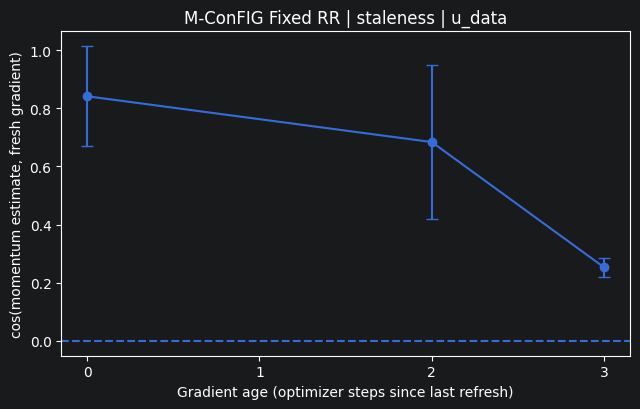

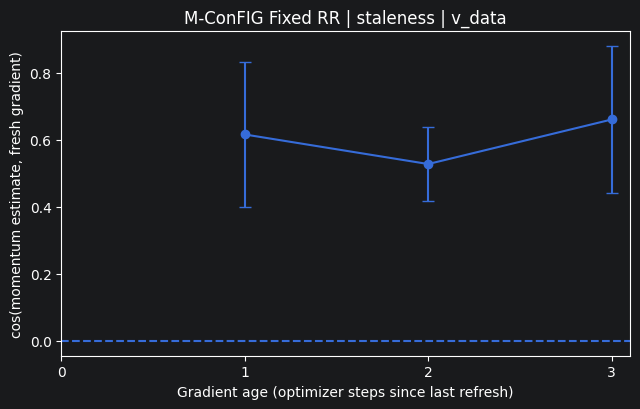

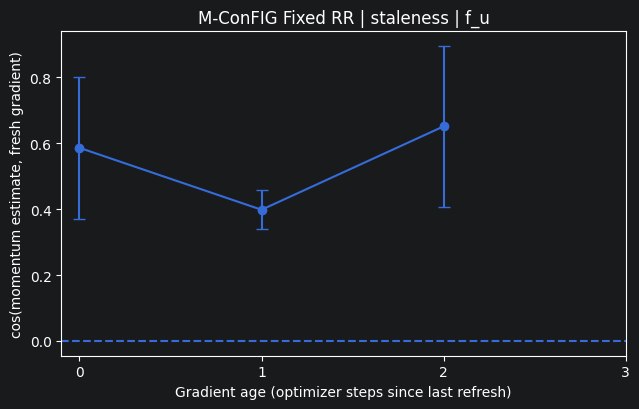

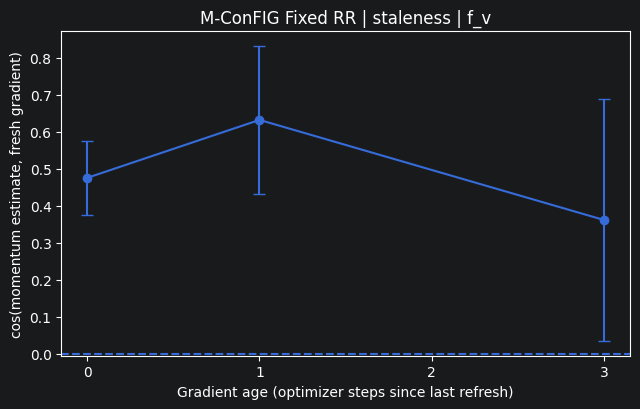

In [21]:

# 1) 每个 task：age -> estimate/fresh cosine
for task in LOSS_KEYS:
    rows = [
        r for r in staleness_rows
        if r["task"] == task
        and int(r["n"]) > 0
    ]
    if not rows:
        continue

    xs = [int(r["age"]) for r in rows]
    ys = [float(r["mean_estimate_fresh_cosine"]) for r in rows]
    es = [
        0.0
        if not np.isfinite(float(r["std_estimate_fresh_cosine"]))
        else float(r["std_estimate_fresh_cosine"])
        for r in rows
    ]

    plt.figure(figsize=(6.5, 4.2))
    plt.errorbar(xs, ys, yerr=es, fmt="o-", capsize=4)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Gradient age (optimizer steps since last refresh)")
    plt.ylabel("cos(momentum estimate, fresh gradient)")
    plt.title(f"M-ConFIG Fixed RR | staleness | {task}")
    plt.xticks([0, 1, 2, 3])
    plt.tight_layout()
    plt.savefig(
        AGG_DIR / f"staleness_cosine_{task}.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()


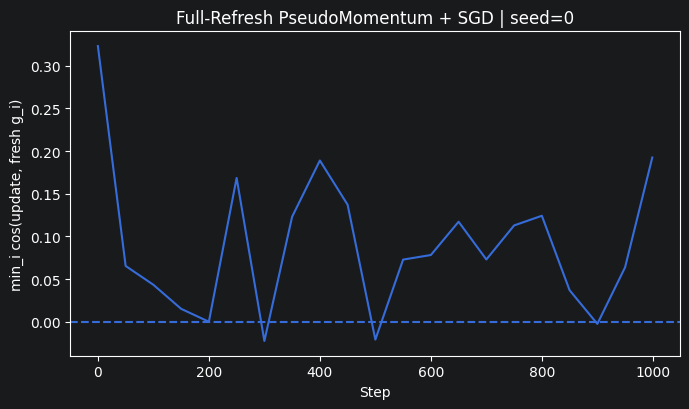

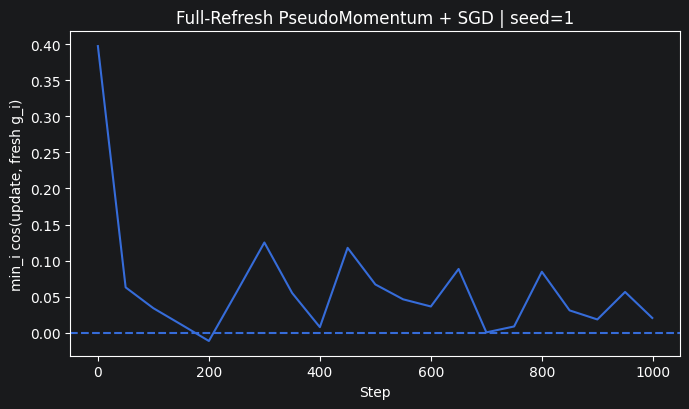

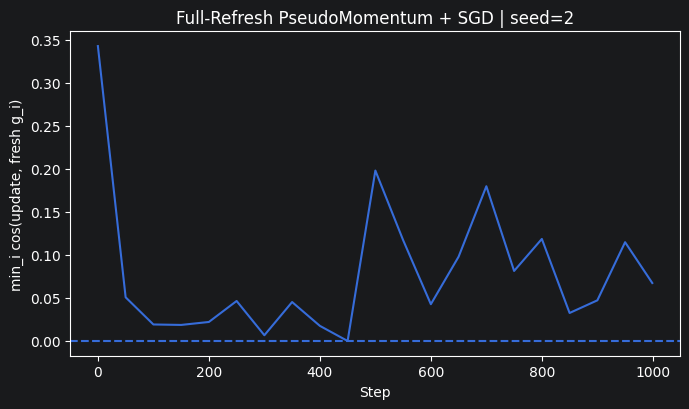

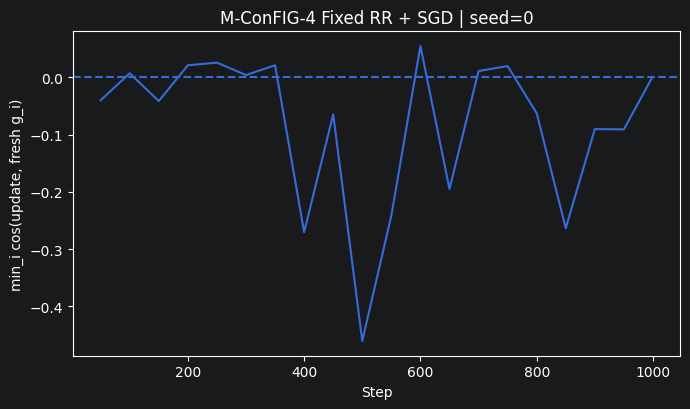

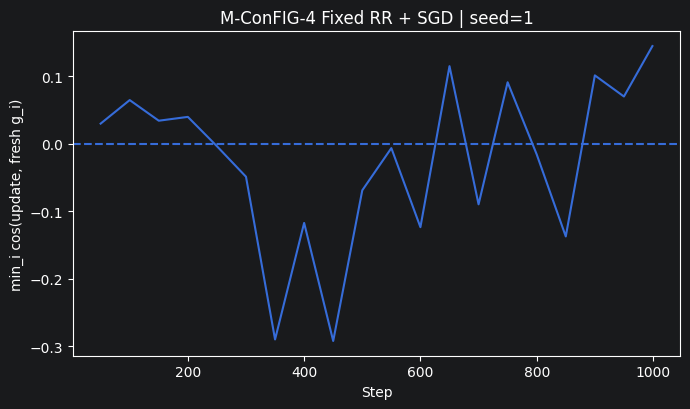

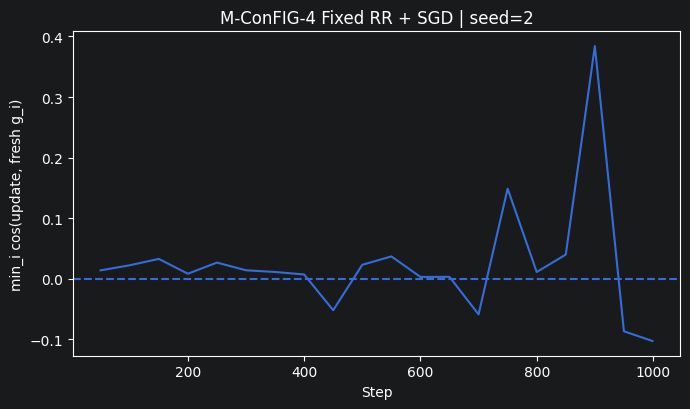

In [22]:

# 2) 每个方法：probe 时的 min update-vs-fresh alignment 轨迹，按 seed 单独画。
for method in METHODS:
    label = model_name(method)

    for seed in RUN_SEEDS:
        rows = [
            r for r in all_probe_rows
            if r["method"] == label
            and int(r["seed"]) == seed
        ]
        if not rows:
            continue

        rows = sorted(rows, key=lambda r: int(r["step"]))

        plt.figure(figsize=(7, 4.2))
        plt.plot(
            [int(r["step"]) for r in rows],
            [float(r["min_update_fresh_alignment"]) for r in rows],
        )
        plt.axhline(0, linestyle="--")
        plt.xlabel("Step")
        plt.ylabel("min_i cos(update, fresh g_i)")
        plt.title(f"{label} | seed={seed}")
        plt.tight_layout()
        safe = method.replace("/", "_")
        plt.savefig(
            AGG_DIR / f"{safe}_seed_{seed}_min_update_fresh_alignment.png",
            dpi=220,
            bbox_inches="tight",
        )
        plt.show()


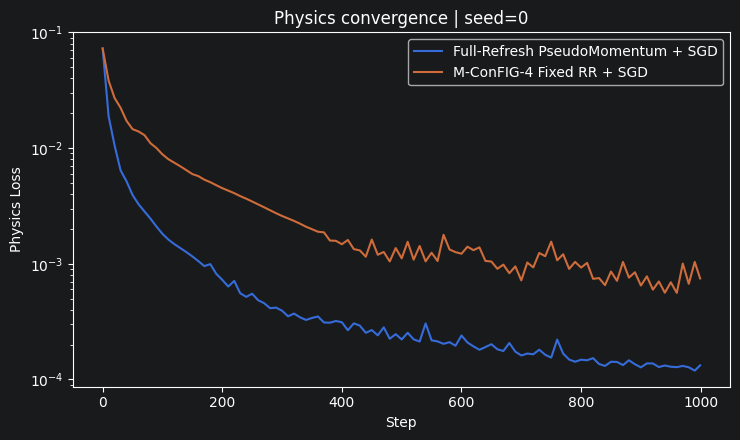

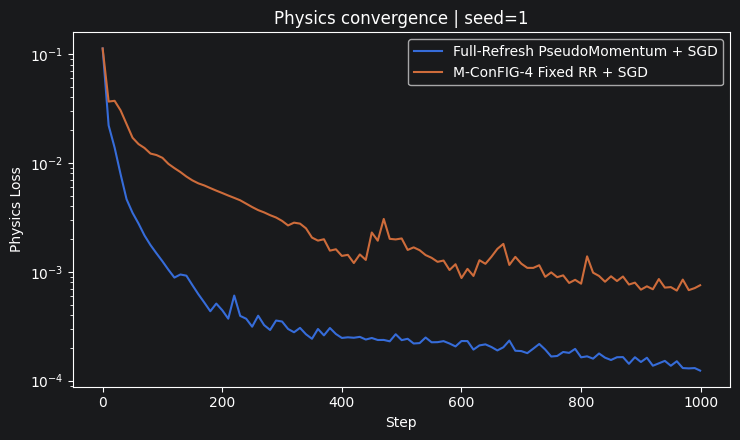

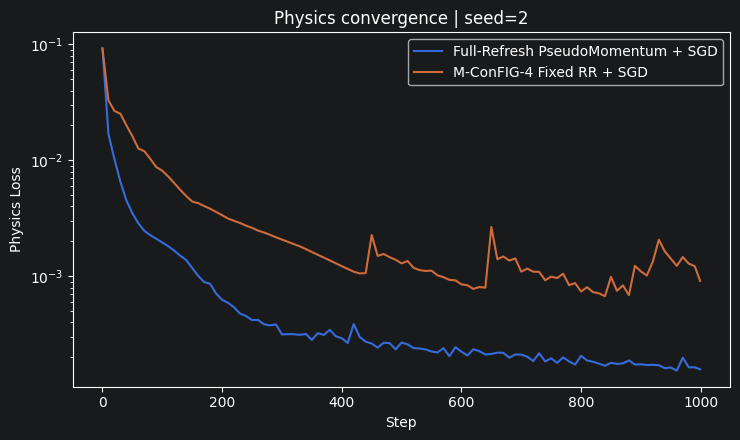

In [23]:

# 3) physics loss：同一 seed 两方法对比。
for seed in RUN_SEEDS:
    plt.figure(figsize=(7.5, 4.5))

    plotted = False
    for method in METHODS:
        label = model_name(method)
        rows = [
            r for r in all_metric_rows
            if r["method"] == label
            and int(r["seed"]) == seed
        ]
        if not rows:
            continue

        rows = sorted(rows, key=lambda r: int(r["step"]))
        plt.semilogy(
            [int(r["step"]) for r in rows],
            [float(r["physics"]) for r in rows],
            label=label,
        )
        plotted = True

    if plotted:
        plt.xlabel("Step")
        plt.ylabel("Physics Loss")
        plt.title(f"Physics convergence | seed={seed}")
        plt.legend()
        plt.tight_layout()
        plt.savefig(
            AGG_DIR / f"seed_{seed}_physics_full_vs_fixed.png",
            dpi=220,
            bbox_inches="tight",
        )
        plt.show()
    else:
        plt.close()


## 22. Field accuracy 3-seed mean ± std 图

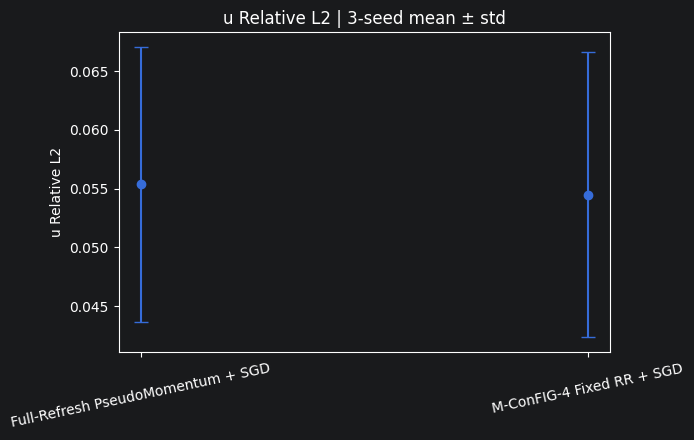

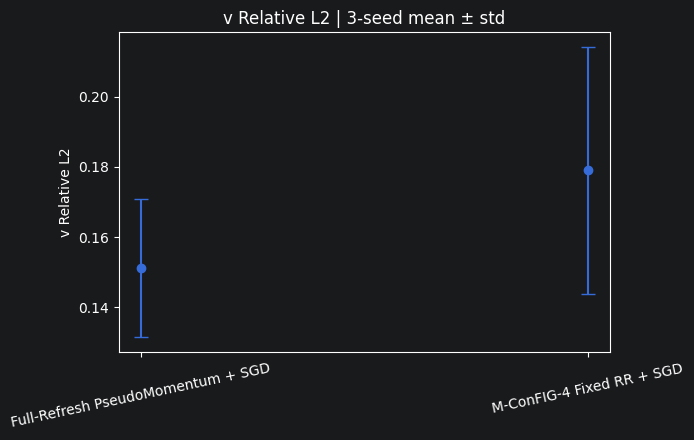

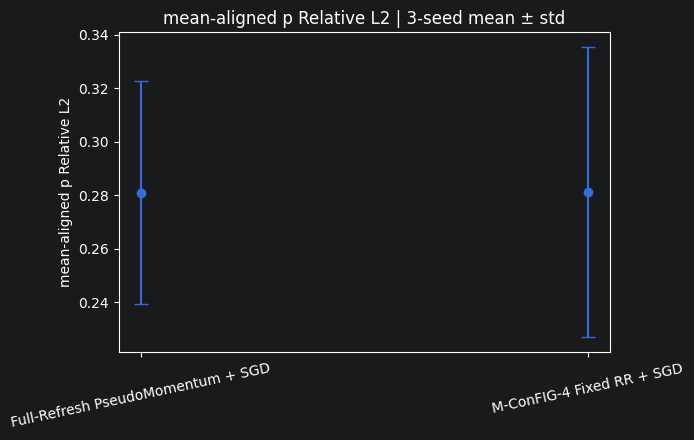

In [24]:

for metric, ylabel in [
    ("u_relative_l2", "u Relative L2"),
    ("v_relative_l2", "v Relative L2"),
    ("p_mean_aligned_relative_l2", "mean-aligned p Relative L2"),
]:
    rows = [
        r for r in summary_rows
        if r["metric"] == metric
    ]
    if not rows:
        continue

    methods = [r["method"] for r in rows]
    means = [float(r["mean"]) for r in rows]
    stds = [
        0.0 if not np.isfinite(float(r["std"])) else float(r["std"])
        for r in rows
    ]
    x = np.arange(len(methods))

    plt.figure(figsize=(7, 4.5))
    plt.errorbar(x, means, yerr=stds, fmt="o", capsize=5)
    plt.xticks(x, methods, rotation=12)
    plt.ylabel(ylabel)
    plt.title(f"{ylabel} | 3-seed mean ± std")
    plt.tight_layout()
    plt.savefig(
        AGG_DIR / f"{metric}_mean_std.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()



## 23. 如何判读这轮实验

### 最理想、最支持后续 dynamic refresh 的情况

如果看到：

```text
fixed RR
fresh refreshes: ~1000 vs full ~4000
wall time: 明显下降
field accuracy: 只小幅下降或基本持平
physics time-to-target: 仍有竞争力
```

同时：

```text
age 0 -> 1 -> 2 -> 3
estimate-vs-fresh cosine 明显下降
而且不同 task 的下降速度不同
```

那么下一步动态策略就有明确问题可以解决：

> “不要机械地每四步刷新一次，而是优先刷新已经变旧、方向失真的 task。”

### 如果 fixed RR 精度明显崩掉

先看：

1. `cos_estimate_fresh_*` 是否很低；
2. `min_update_fresh_alignment` 是否大量低于 0；
3. 是 data task 还是 physics task 先失真；
4. physics threshold 是从一开始就慢，还是后期才掉队；
5. full-refresh pseudo control 本身是否也表现差。

如果 full-refresh pseudo 也差，问题可能主要来自 **SGD / pseudo-momentum / LR 适配**，不能把锅直接归给 round-robin staleness。

### 如果 fixed RR 与 full-refresh 几乎一样

这也是有价值的：

> 当前 4-loss 问题里，0–3 step 的 staleness 可能很可接受。

这种情况下不应为了“创新”强行做复杂 dynamic scheduler。下一步更值得增加更高 loss 数量、更稀疏观测、不同 PDE / backbone，看看 staleness 什么时候真正成为瓶颈。

### 如果 wall time 几乎没降

检查：

- fixed RR 是否真的走了 `compute_single_task_loss()`；
- `diagnostic_time_s` 是否占比过高；
- 高阶 PDE forward 是否主导总成本；
- 后续应补 diagnostics-off pure profiler。

不能因为 task-gradient count 从 4000 降到 1000，就自动宣称实际训练加速 4 倍。


## 24. 可选：把已有 ConFIG-4 结果作为“历史上下文”读进来

In [25]:

PREVIOUS_COMPARISON = (
    PREVIOUS_4LOSS_ROOT
    / "aggregate"
    / "comparison_adam_config2_config4.csv"
)

if PREVIOUS_COMPARISON.exists():
    print("Previous Adam / ConFIG-2 / ConFIG-4 context:")
    previous_rows = read_rows(PREVIOUS_COMPARISON)
    for row in previous_rows:
        if row["metric"] in [
            "u_relative_l2",
            "v_relative_l2",
            "p_mean_aligned_relative_l2",
            "mean_physics_loss",
            "wall_time_min",
            "peak_vram_mib",
        ]:
            print(row)

    print()
    print(
        "Reminder: previous ConFIG-4 uses Adam; "
        "current M-ConFIG controls use SGD + PseudoMomentum. "
        "Do not attribute cross-table differences solely to refresh policy."
    )
else:
    print("Previous 4-loss comparison file not found; skip context.")


Previous Adam / ConFIG-2 / ConFIG-4 context:
{'metric': 'u_relative_l2', 'method': 'Adam Simple-Sum', 'n': '3', 'mean': '0.04353709819210579', 'std': '0.012063086143822451'}
{'metric': 'u_relative_l2', 'method': 'Adam + ConFIG-2', 'n': '3', 'mean': '0.0375663997440752', 'std': '0.00566259224305482'}
{'metric': 'u_relative_l2', 'method': 'Adam + ConFIG-4', 'n': '3', 'mean': '0.0378612097161656', 'std': '0.0052125474981746505'}
{'metric': 'v_relative_l2', 'method': 'Adam Simple-Sum', 'n': '3', 'mean': '0.14090229736434404', 'std': '0.019650399195862304'}
{'metric': 'v_relative_l2', 'method': 'Adam + ConFIG-2', 'n': '3', 'mean': '0.13982233828615764', 'std': '0.024072400795855545'}
{'metric': 'v_relative_l2', 'method': 'Adam + ConFIG-4', 'n': '3', 'mean': '0.12963138097670088', 'std': '0.0081668060448487'}
{'metric': 'p_mean_aligned_relative_l2', 'method': 'Adam Simple-Sum', 'n': '3', 'mean': '0.2793824215891405', 'std': '0.07101922900672543'}
{'metric': 'p_mean_aligned_relative_l2', 'met

## 25. 预期输出

In [26]:

print(OUTPUT_ROOT.resolve())

print(
    """
Expected structure:

navier_stokes_mconfig4_fixed_roundrobin/
├── seed_0/
│   ├── full_refresh_pseudo_sgd/
│   │   ├── model.pt
│   │   ├── metric_history.csv
│   │   ├── probe_history.csv
│   │   ├── field_metrics.csv
│   │   ├── threshold_steps.csv
│   │   ├── predictions.npz
│   │   └── run_meta.json
│   └── mconfig4_fixed_roundrobin/
│       └── ...
├── seed_1/
├── seed_2/
└── aggregate/
    ├── all_field_metrics.csv
    ├── all_metric_history.csv
    ├── all_probe_history.csv
    ├── all_threshold_steps.csv
    ├── all_run_meta.csv
    ├── mean_std_summary.csv
    ├── threshold_mean_std.csv
    ├── staleness_by_task_age.csv
    ├── update_fresh_alignment_summary.csv
    ├── fixed_vs_full_refresh_summary.csv
    └── *.png
"""
)


/home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_mconfig4_fixed_roundrobin

Expected structure:

navier_stokes_mconfig4_fixed_roundrobin/
├── seed_0/
│   ├── full_refresh_pseudo_sgd/
│   │   ├── model.pt
│   │   ├── metric_history.csv
│   │   ├── probe_history.csv
│   │   ├── field_metrics.csv
│   │   ├── threshold_steps.csv
│   │   ├── predictions.npz
│   │   └── run_meta.json
│   └── mconfig4_fixed_roundrobin/
│       └── ...
├── seed_1/
├── seed_2/
└── aggregate/
    ├── all_field_metrics.csv
    ├── all_metric_history.csv
    ├── all_probe_history.csv
    ├── all_threshold_steps.csv
    ├── all_run_meta.csv
    ├── mean_std_summary.csv
    ├── threshold_mean_std.csv
    ├── staleness_by_task_age.csv
    ├── update_fresh_alignment_summary.csv
    ├── fixed_vs_full_refresh_summary.csv
    └── *.png




# 26. 这轮跑完后，把哪些文件发给我

优先发这 5 个：

```text
aggregate/mean_std_summary.csv
aggregate/threshold_mean_std.csv
aggregate/staleness_by_task_age.csv
aggregate/update_fresh_alignment_summary.csv
aggregate/fixed_vs_full_refresh_summary.csv
```

如果出现异常，再补：

```text
aggregate/all_probe_history.csv
seed_*/mconfig4_fixed_roundrobin/run_meta.json
```

下一轮分析的核心不是单看“谁的 Relative L2 最低”，而是建立完整因果链：

$$
\text{减少真实梯度刷新}
\rightarrow
\text{产生 staleness}
\rightarrow
\text{estimate 与 fresh gradient 偏离}
\rightarrow
\text{公共更新方向发生变化}
\rightarrow
\text{accuracy / physics / time-to-target 改变}.
$$

只有这条链真的出现，才有依据继续设计 conflict/staleness/cost-aware dynamic M-ConFIG。
